# 🌡️ Global Temperature EDA
> **Dataset:** Berkeley Earth Surface Temperature · 5 CSVs · 1750 – 2015  
> **Sections:** Setup → Data Loading → Preprocessing → Missing Values →  
> Global Trends → Seasonal Patterns → Country Analysis → City Analysis →  
> Distributions → Warming Analysis → Geo-Visualisation


## 1. Setup & Imports

In [33]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')
from src.data_loader import load_dataset
from src.preprocessing import preprocess

# Project modules
from src.data_loader   import load_dataset
from src.preprocessing import preprocess, missing_value_report
from src.analysis      import (
    summary_stats, correlation_matrix,
    global_yearly_trend, global_seasonal_trend,
    top_warming_countries, country_yearly_trend, country_monthly_profile,
    top_hottest_cities, top_coldest_cities, city_yearly_trend,
    temperature_distribution, monthly_boxplot_data,
)
from src.visualization import (
    plot_global_trend, plot_seasonal_trend,
    plot_top_warming_countries, plot_country_trend, plot_country_monthly_profile,
    plot_hottest_cities, plot_coldest_cities,
    plot_temperature_distribution, plot_monthly_boxplot,
    plot_correlation_heatmap, plot_temperature_map, plot_country_choropleth,
)

# Matplotlib dark style
plt.rcParams.update({
    'figure.facecolor': '#0E1117',
    'axes.facecolor':   '#1A1D2E',
    'axes.edgecolor':   '#333',
    'axes.labelcolor':  '#E0E0E0',
    'xtick.color':      '#A0A0B0',
    'ytick.color':      '#A0A0B0',
    'text.color':       '#E0E0E0',
    'grid.color':       '#2A2D3E',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'figure.dpi':       120,
    'font.family':      'sans-serif',
})
CYAN   = '#00D4FF'
RED    = '#FF6B6B'
AMBER  = '#FFD166'
GREEN  = '#55EFC4'
print('✅  All imports successful')


✅  All imports successful


## 2. Data Loading

In [34]:
# Load and preprocess all datasets
print('Loading global temperatures...')
g_df  = preprocess(load_dataset('global'))

print('Loading country temperatures...')
c_df  = preprocess(load_dataset('country'))

print('Loading major-city temperatures...')
mc_df = preprocess(load_dataset('major_city'))

print('Loading state temperatures...')
s_df  = preprocess(load_dataset('state'))

print('\n✅  All datasets loaded!')
print(f'  Global     : {g_df.shape}')
print(f'  Country    : {c_df.shape}')
print(f'  Major City : {mc_df.shape}')
print(f'  State      : {s_df.shape}')


Loading global temperatures...
Loading country temperatures...
Loading major-city temperatures...
Loading state temperatures...

✅  All datasets loaded!
  Global     : (3180, 14)
  Country    : (544811, 8)
  Major City : (228175, 11)
  State      : (620027, 9)


In [35]:
# Quick peek at each dataset
for name, df in [('Global', g_df), ('Country', c_df), ('Major City', mc_df)]:
    print(f'\n{'─'*60}')
    print(f'  {name}  —  columns: {list(df.columns)}')
    display(df.head(3))



────────────────────────────────────────────────────────────
  Global  —  columns: ['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty', 'LandMaxTemperature', 'LandMaxTemperatureUncertainty', 'LandMinTemperature', 'LandMinTemperatureUncertainty', 'LandAndOceanAverageTemperature', 'LandAndOceanAverageTemperatureUncertainty', 'year', 'month', 'decade', 'season', 'AverageTemperature']


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty,year,month,decade,season,AverageTemperature
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN,1750,1,1750,Winter,3.034
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN,1750,2,1750,Winter,3.083
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN,1750,3,1750,Spring,5.626



────────────────────────────────────────────────────────────
  Country  —  columns: ['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'Country', 'year', 'month', 'decade', 'season']


,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year,month,decade,season
0,1743-11-01,4.384,2.294,Åland,1743,11,1740,Autumn
5,1744-04-01,1.530,4.680,Åland,1744,4,1740,Spring
6,1744-05-01,6.702,1.789,Åland,1744,5,1740,Spring



────────────────────────────────────────────────────────────
  Major City  —  columns: ['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'City', 'Country', 'Latitude', 'Longitude', 'year', 'month', 'decade', 'season']


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,year,month,decade,season
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63,-3.23,1849,1,1840,Winter
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63,-3.23,1849,2,1840,Winter
2,1849-03-01,28.101,1.612,Abidjan,Côte D'Ivoire,5.63,-3.23,1849,3,1840,Spring


## 3. Preprocessing & Missing Value Audit

In [36]:
for name, df in [('Global', g_df), ('Country', c_df), ('Major City', mc_df), ('State', s_df)]:
    mv = missing_value_report(df)
    print(f'\n── {name} ─────────────────────────────')
    if mv.empty:
        print('   ✅ No missing values')
    else:
        display(mv)



── Global ─────────────────────────────


,Missing Count,Missing %
LandMaxTemperature,1188,37.36
LandMaxTemperatureUncertainty,1188,37.36
LandMinTemperature,1188,37.36
LandMinTemperatureUncertainty,1188,37.36
LandAndOceanAverageTemperature,1188,37.36
LandAndOceanAverageTemperatureUncertainty,1188,37.36



── Country ─────────────────────────────
   ✅ No missing values

── Major City ─────────────────────────────
   ✅ No missing values

── State ─────────────────────────────
   ✅ No missing values


In [37]:
# Visualise missing-value % for major-city dataset
mv = missing_value_report(mc_df)
if not mv.empty:
    fig, ax = plt.subplots(figsize=(7, 3))
    mv['Missing %'].plot(kind='barh', ax=ax, color=RED)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values — Major City Dataset', color=CYAN)
    plt.tight_layout(); plt.show()


## 4. Descriptive Statistics

In [38]:
print('=== Global Dataset ===')
display(summary_stats(g_df))


=== Global Dataset ===


,count,mean,min,25%,50%,75%,max,std
dt,3180,1883-06-14 11:37:21.509433856,1750-01-01 00:00:00,1817-03-24 06:00:00,1883-06-16 00:00:00,1949-09-08 12:00:00,2015-12-01 00:00:00,NaN
LandAverageTemperature,3180.0,8.374731,-2.08,4.312,8.6105,12.54825,19.021,4.38131
LandAverageTemperatureUncertainty,3180.0,0.938468,0.034,0.18675,0.392,1.41925,7.88,1.09644
LandMaxTemperature,1992.0,14.350601,5.9,10.212,14.76,18.4515,21.32,4.309579
LandMaxTemperatureUncertainty,1992.0,0.479782,0.044,0.142,0.252,0.539,4.373,0.583203
LandMinTemperature,1992.0,2.743595,-5.407,-1.3345,2.9495,6.77875,9.715,4.155835
LandMinTemperatureUncertainty,1992.0,0.431849,0.045,0.155,0.279,0.45825,3.498,0.445838
LandAndOceanAverageTemperature,1992.0,15.212566,12.475,14.047,15.251,16.39625,17.611,1.274093
LandAndOceanAverageTemperatureUncertainty,1992.0,0.128532,0.042,0.063,0.122,0.151,0.457,0.073587
year,3180.0,1882.994654,1750.0,1817.0,1883.0,1949.0,2015.0,76.519632


In [39]:
print('=== Country Dataset ===')
display(summary_stats(c_df))


=== Country Dataset ===


,count,mean,min,25%,50%,75%,max,std
dt,544811,1913-08-08 18:20:24.887162624,1743-11-01 00:00:00,1869-11-01 00:00:00,1919-08-01 00:00:00,1966-10-01 00:00:00,2013-09-01 00:00:00,NaN
AverageTemperature,544811.0,17.193354,-37.658,10.025,20.901,25.814,38.842,10.953966
AverageTemperatureUncertainty,544811.0,1.01919,0.052,0.323,0.571,1.207,15.003,1.202634
year,544811.0,1913.145696,1743.0,1869.0,1919.0,1966.0,2013.0,64.346358
month,544811.0,6.491932,1.0,3.0,6.0,9.0,12.0,3.451034
decade,544811.0,1908.661866,1740.0,1860.0,1910.0,1960.0,2010.0,64.431871


## 5. Global Land Temperature Trend

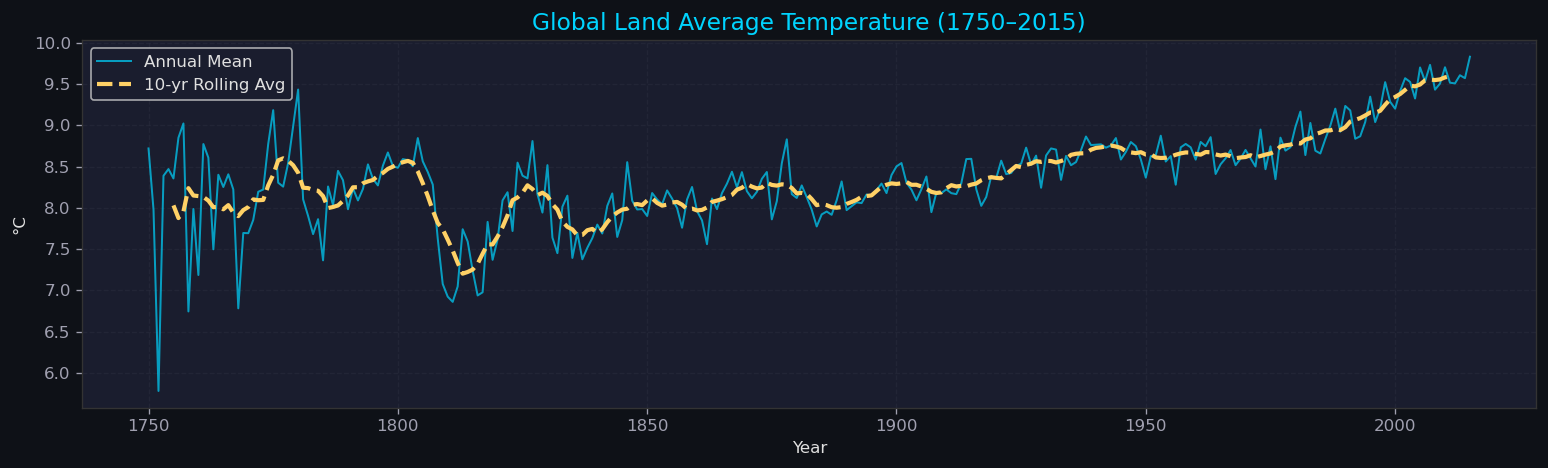

In [40]:
yearly = global_yearly_trend(g_df)
rolling = yearly['MeanTemp'].rolling(10, center=True).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(yearly['year'], yearly['MeanTemp'], color=CYAN, lw=1.2, alpha=0.7, label='Annual Mean')
ax.plot(yearly['year'], rolling, color=AMBER, lw=2.5, linestyle='--', label='10-yr Rolling Avg')
ax.set_title('Global Land Average Temperature (1750–2015)', fontsize=14, color=CYAN)
ax.set_xlabel('Year'); ax.set_ylabel('°C')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


In [41]:
# Interactive Plotly version
plot_global_trend(yearly).show()


## 6. Seasonal Temperature Patterns

In [42]:
seasonal = global_seasonal_trend(g_df)
print(seasonal.head())


   year  season   MeanTemp
0  1750  Autumn   8.890000
1  1750  Spring   8.563000
2  1750  Summer  14.518333
3  1750  Winter   2.963000
4  1751  Autumn  10.673000


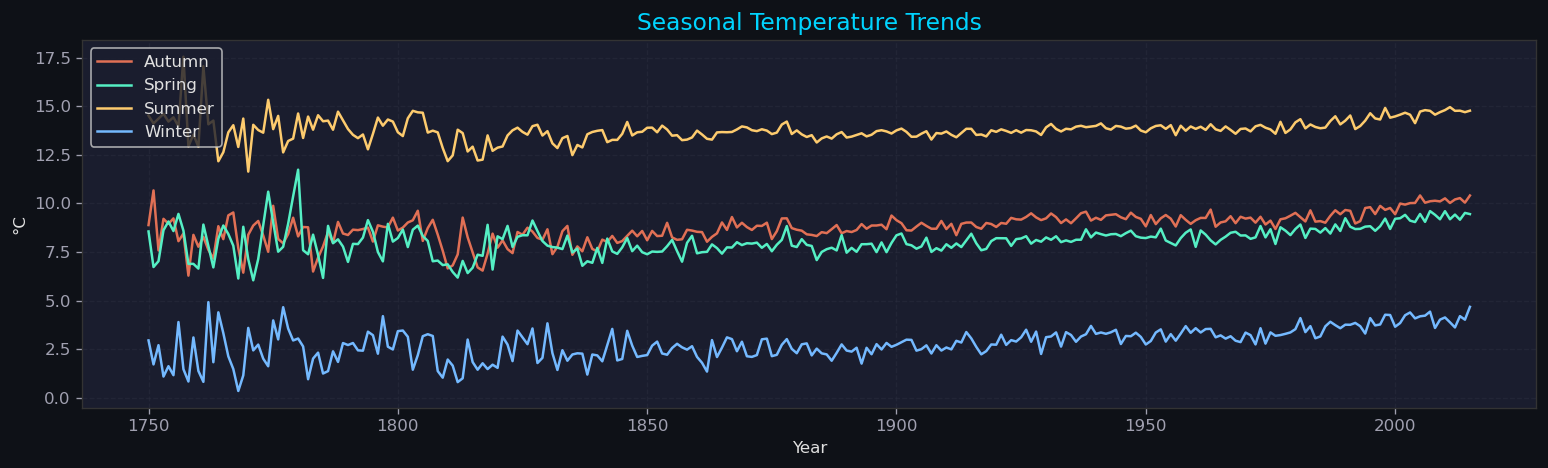

In [43]:
season_palette = {'Winter':'#74B9FF','Spring':'#55EFC4','Summer':'#FDCB6E','Autumn':'#E17055'}
fig, ax = plt.subplots(figsize=(13, 4))
for season, grp in seasonal.groupby('season'):
    ax.plot(grp['year'], grp['MeanTemp'], label=season,
            color=season_palette.get(season, CYAN), lw=1.5)
ax.set_title('Seasonal Temperature Trends', fontsize=14, color=CYAN)
ax.set_xlabel('Year'); ax.set_ylabel('°C')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


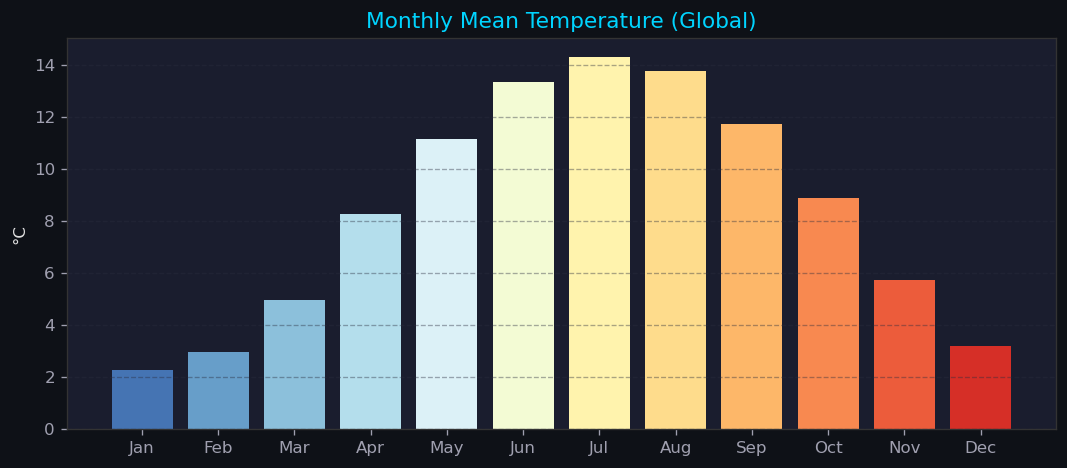

In [44]:
# Monthly climatology (all global records)
monthly_avg = g_df.groupby('month')['AverageTemperature'].mean()
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(MONTHS, monthly_avg.values,
              color=plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, 12)))
ax.set_title('Monthly Mean Temperature (Global)', fontsize=13, color=CYAN)
ax.set_ylabel('°C'); ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()


## 7. Correlation Analysis

In [45]:
corr = correlation_matrix(g_df)
print(corr)


                                           LandAverageTemperature  \
LandAverageTemperature                                   1.000000   
LandAverageTemperatureUncertainty                       -0.204191   
LandMaxTemperature                                       0.995807   
LandMaxTemperatureUncertainty                           -0.108462   
LandMinTemperature                                       0.995611   
LandMinTemperatureUncertainty                           -0.167451   
LandAndOceanAverageTemperature                           0.988066   
LandAndOceanAverageTemperatureUncertainty               -0.131412   
year                                                     0.081449   
month                                                    0.245935   
decade                                                   0.081407   
AverageTemperature                                       1.000000   

                                           LandAverageTemperatureUncertainty  \
LandAverageTemperature

In [46]:
# Plotly heatmap
plot_correlation_heatmap(corr).show()


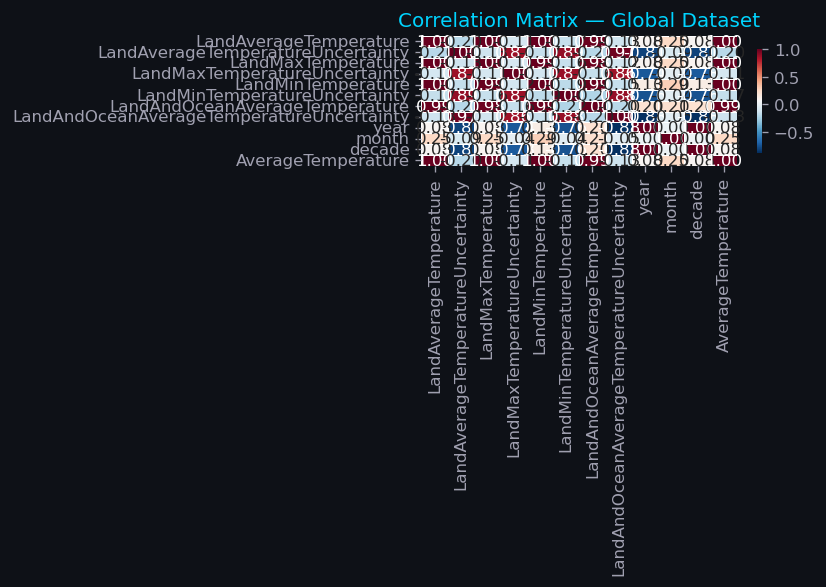

In [47]:
# Seaborn version
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Correlation Matrix — Global Dataset', color=CYAN)
plt.tight_layout(); plt.show()


## 8. Country-Level Analysis

In [48]:
# Top warming countries
warming = top_warming_countries(c_df, n=15)
display(warming)


,Country,EarlyMean,LateMean,Warming
0,Estonia,4.397022,5.866334,1.469313
1,Latvia,4.911788,6.370379,1.458591
2,Finland,0.821745,2.257598,1.435854
3,Belarus,5.449500,6.881374,1.431874
4,Saint Pierre And Miquelon,3.727178,5.146305,1.419128
5,Lithuania,5.519040,6.934416,1.415376
6,Sweden,1.968791,3.345059,1.376268
7,Åland,4.882928,6.237427,1.354499
8,Norway,-0.297072,1.035177,1.332249
9,Ukraine,7.317583,8.633902,1.316319


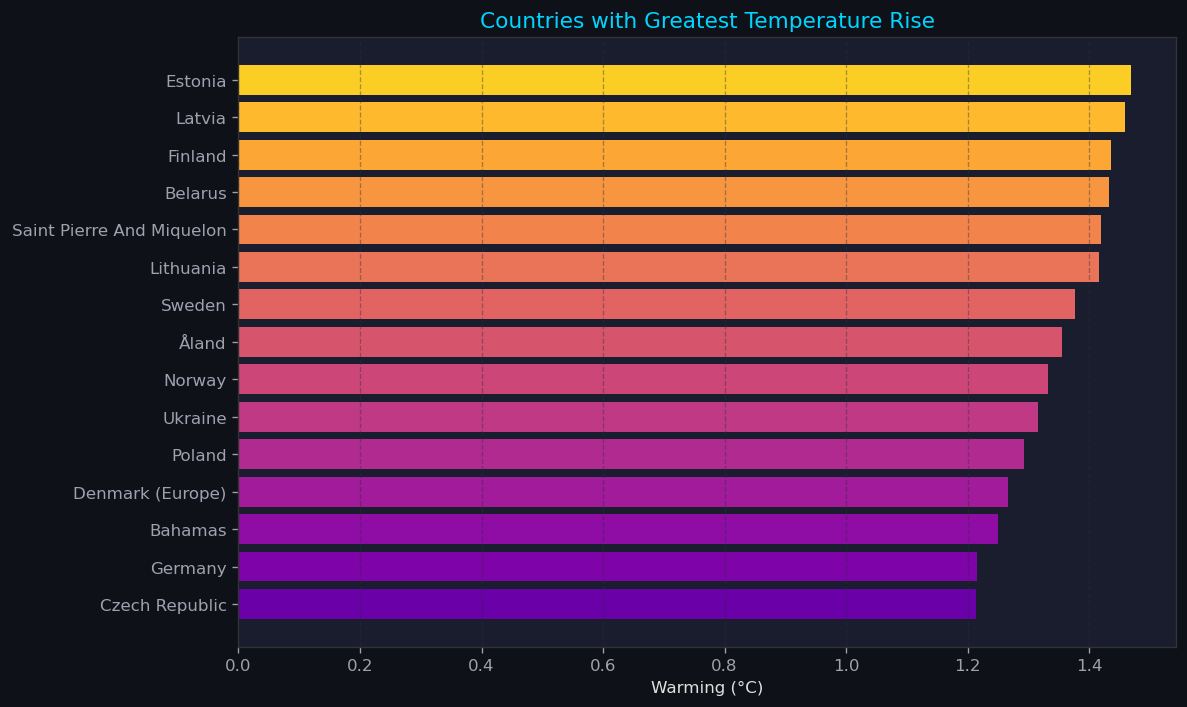

In [49]:
# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(warming)))
ax.barh(warming['Country'], warming['Warming'], color=colors[::-1])
ax.set_title('Countries with Greatest Temperature Rise', fontsize=13, color=CYAN)
ax.set_xlabel('Warming (°C)')
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()


In [50]:
# Plotly interactive
plot_top_warming_countries(warming).show()


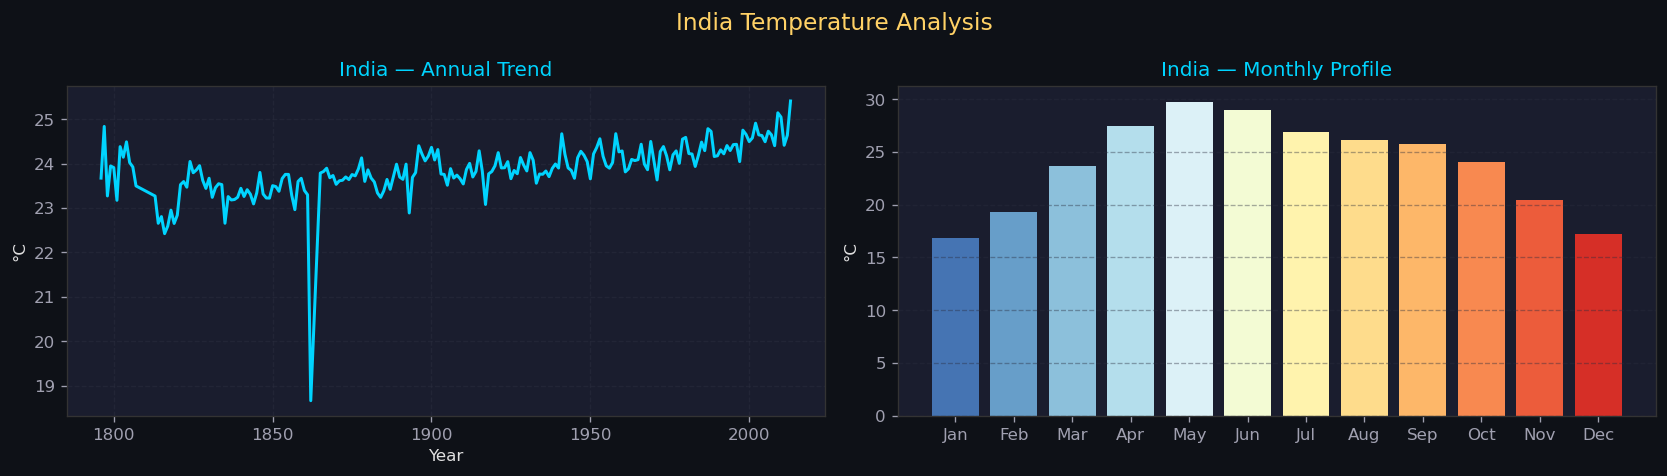

In [51]:
# Single-country deep dive — India
country = 'India'
trend   = country_yearly_trend(c_df, country)
profile = country_monthly_profile(c_df, country)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(trend['year'], trend['MeanTemp'], color=CYAN, lw=1.8)
axes[0].set_title(f'{country} — Annual Trend', color=CYAN)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('°C')
axes[0].grid(True)

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar([MONTHS[m-1] for m in profile['month']], profile['MeanTemp'],
            color=plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, 12)))
axes[1].set_title(f'{country} — Monthly Profile', color=CYAN)
axes[1].set_ylabel('°C'); axes[1].grid(axis='y', alpha=0.4)

plt.suptitle(f'{country} Temperature Analysis', color=AMBER, fontsize=14)
plt.tight_layout(); plt.show()


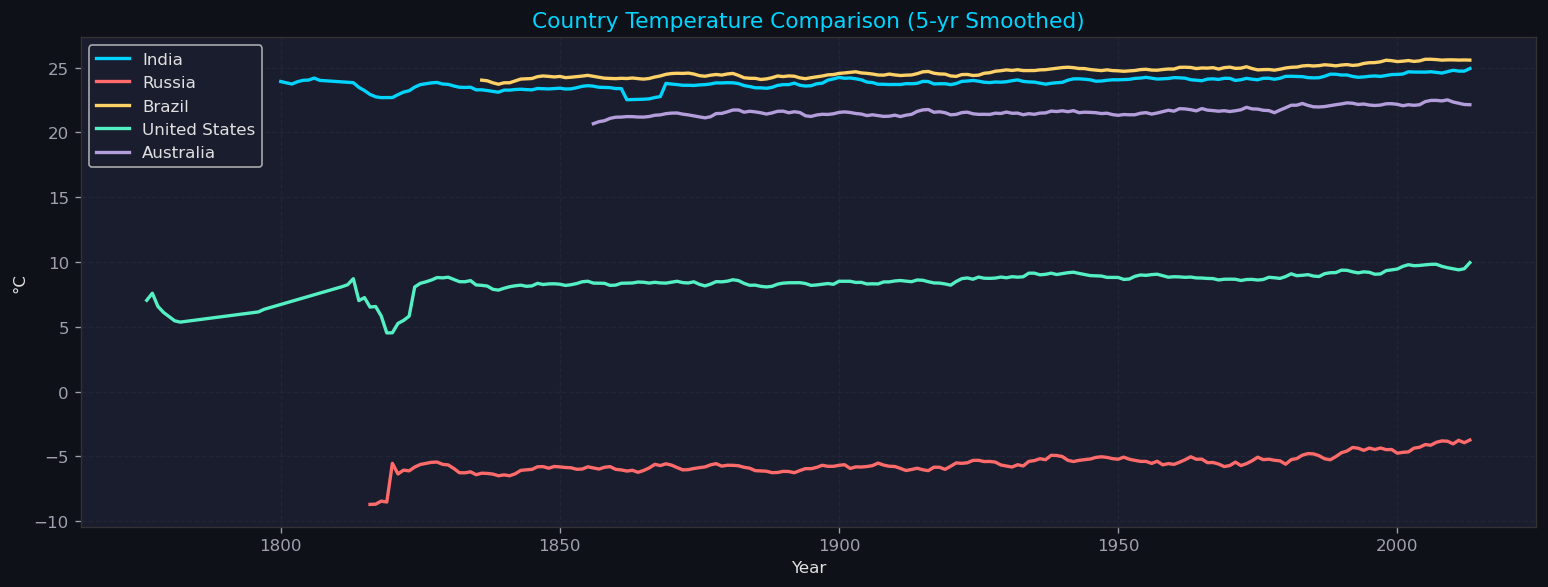

In [52]:
# Compare multiple countries — annual trend overlay
compare_countries = ['India', 'Russia', 'Brazil', 'United States', 'Australia']
COLORS = [CYAN, RED, AMBER, GREEN, '#B39DDB']

fig, ax = plt.subplots(figsize=(13, 5))
for country, color in zip(compare_countries, COLORS):
    tr = country_yearly_trend(c_df, country)
    if not tr.empty:
        ax.plot(tr['year'], tr['MeanTemp'].rolling(5).mean(),
                label=country, color=color, lw=2)
ax.set_title('Country Temperature Comparison (5-yr Smoothed)', fontsize=13, color=CYAN)
ax.set_xlabel('Year'); ax.set_ylabel('°C')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


In [53]:
# World Choropleth
plot_country_choropleth(c_df).show()


## 9. City-Level Analysis

In [54]:
hottest = top_hottest_cities(mc_df, n=15)
coldest = top_coldest_cities(mc_df, n=15)
print('Top 15 Hottest Cities:')
display(hottest)
print('\nTop 15 Coldest Cities:')
display(coldest)


Top 15 Hottest Cities:


,City,Country,MeanTemp
0,Umm Durman,Sudan,29.081291
1,Madras,India,28.417858
2,Jiddah,Saudi Arabia,27.692066
3,Ho Chi Minh City,Vietnam,27.193984
4,Bangkok,Thailand,27.164733
5,Mogadishu,Somalia,27.151964
6,Fortaleza,Brazil,27.008640
7,Hyderabad,India,26.869335
8,Surabaya,Indonesia,26.809904
9,Rangoon,Burma,26.735193



Top 15 Coldest Cities:


,City,Country,MeanTemp
0,Harbin,China,3.625744
1,Saint Petersburg,Russia,3.918045
2,Moscow,Russia,3.999711
3,Montreal,Canada,4.445014
4,Changchun,China,4.923798
5,Santiago,Chile,5.692277
6,Toronto,Canada,5.773911
7,Kiev,Ukraine,7.041033
8,Shenyang,China,7.214980
9,Taiyuan,China,7.976806


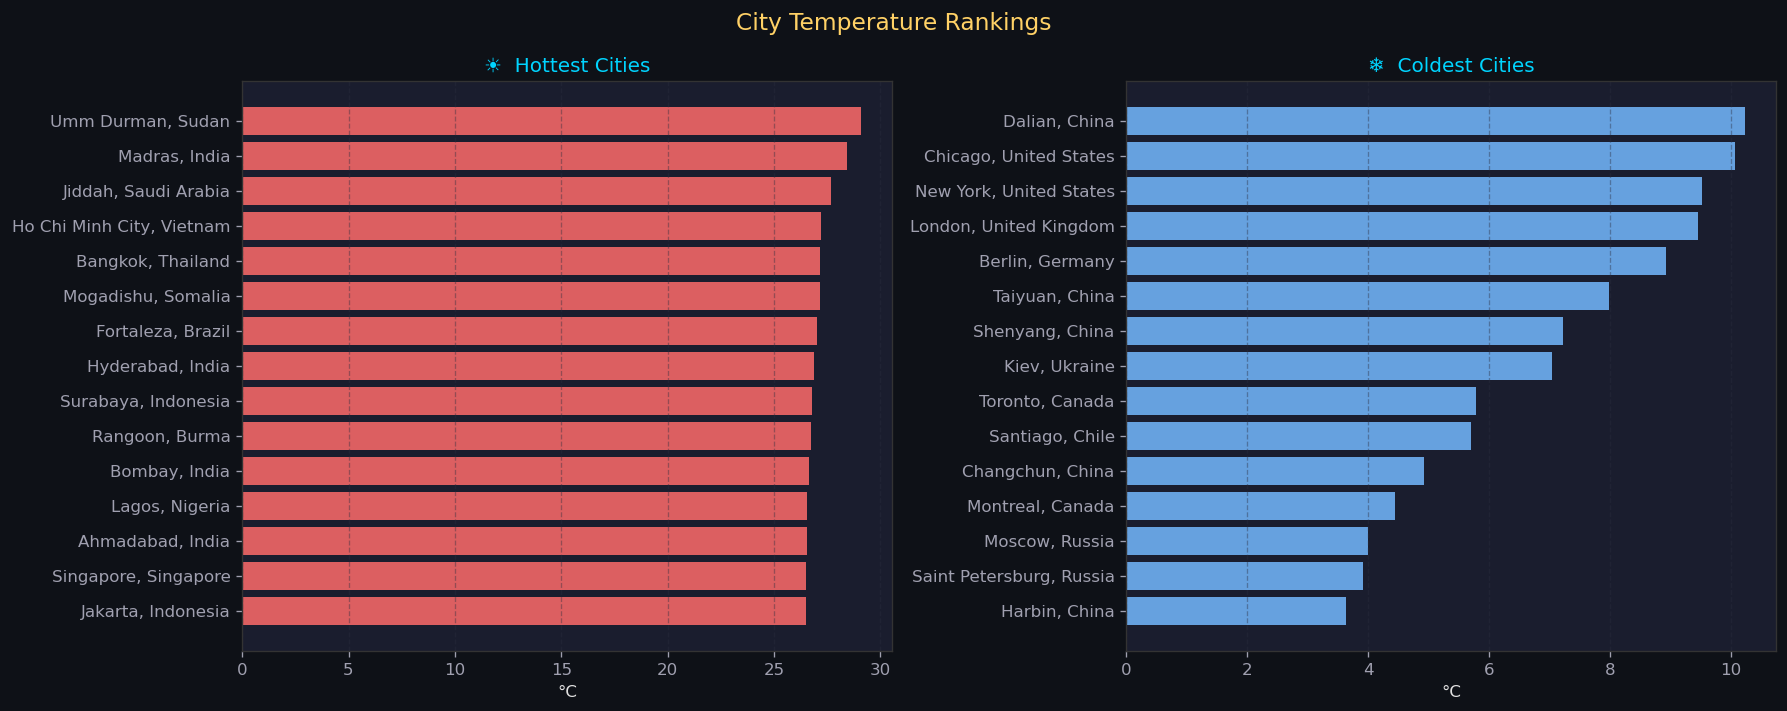

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(hottest['City'] + ', ' + hottest['Country'], hottest['MeanTemp'], color=RED, alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_title('☀️  Hottest Cities', color=CYAN); axes[0].set_xlabel('°C')
axes[0].grid(axis='x', alpha=0.4)

axes[1].barh(coldest['City'] + ', ' + coldest['Country'], coldest['MeanTemp'], color='#74B9FF', alpha=0.85)
axes[1].set_title('❄️  Coldest Cities', color=CYAN); axes[1].set_xlabel('°C')
axes[1].grid(axis='x', alpha=0.4)

plt.suptitle('City Temperature Rankings', color=AMBER, fontsize=14)
plt.tight_layout(); plt.show()


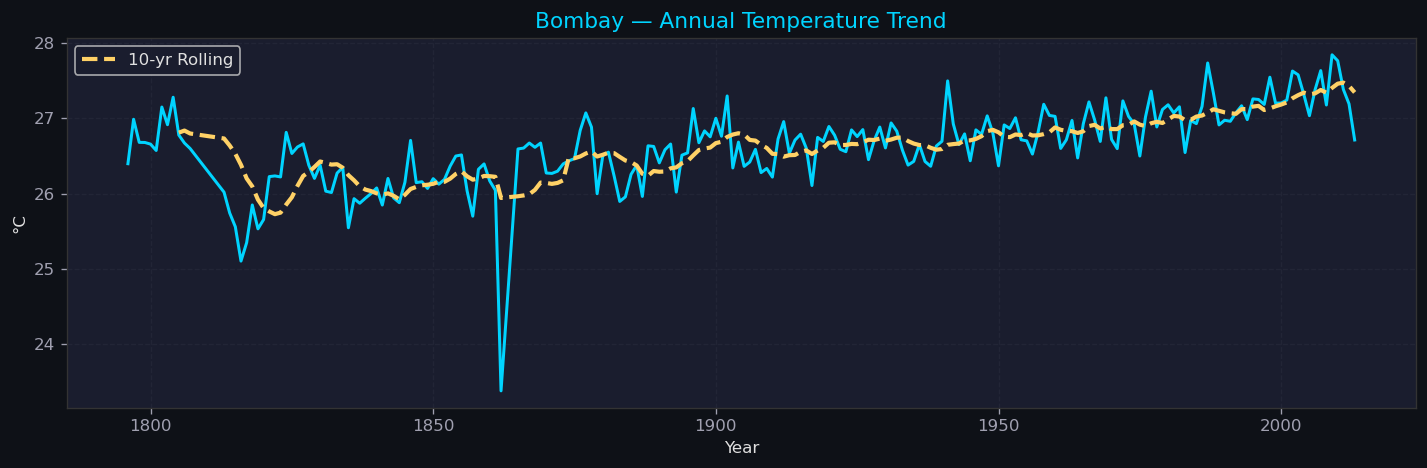

In [56]:
# City trend — Bombay (Mumbai)
city   = 'Bombay'
c_trend = city_yearly_trend(mc_df, city)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(c_trend['year'], c_trend['MeanTemp'], color=CYAN, lw=1.8)
ax.plot(c_trend['year'], c_trend['MeanTemp'].rolling(10).mean(),
        color=AMBER, lw=2.5, linestyle='--', label='10-yr Rolling')
ax.set_title(f'{city} — Annual Temperature Trend', fontsize=13, color=CYAN)
ax.set_xlabel('Year'); ax.set_ylabel('°C')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


In [57]:
# City scatter map
plot_temperature_map(mc_df).show()


## 10. Temperature Distributions

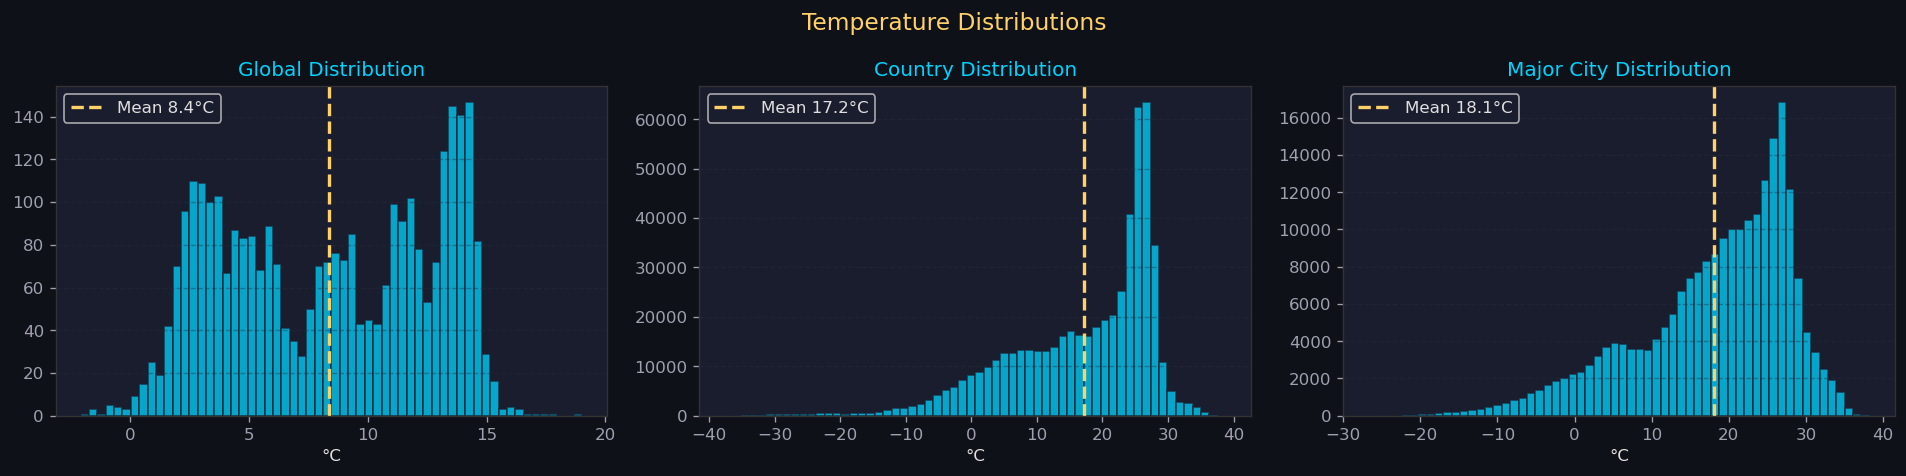

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

datasets_list = [('Global', g_df), ('Country', c_df), ('Major City', mc_df)]
for ax, (name, df) in zip(axes, datasets_list):
    series = temperature_distribution(df)
    ax.hist(series, bins=60, color=CYAN, alpha=0.75, edgecolor='#1A1D2E')
    ax.axvline(series.mean(), color=AMBER, linewidth=2, linestyle='--',
               label=f'Mean {series.mean():.1f}°C')
    ax.set_title(f'{name} Distribution', color=CYAN)
    ax.set_xlabel('°C'); ax.legend(); ax.grid(axis='y', alpha=0.4)

plt.suptitle('Temperature Distributions', color=AMBER, fontsize=14)
plt.tight_layout(); plt.show()


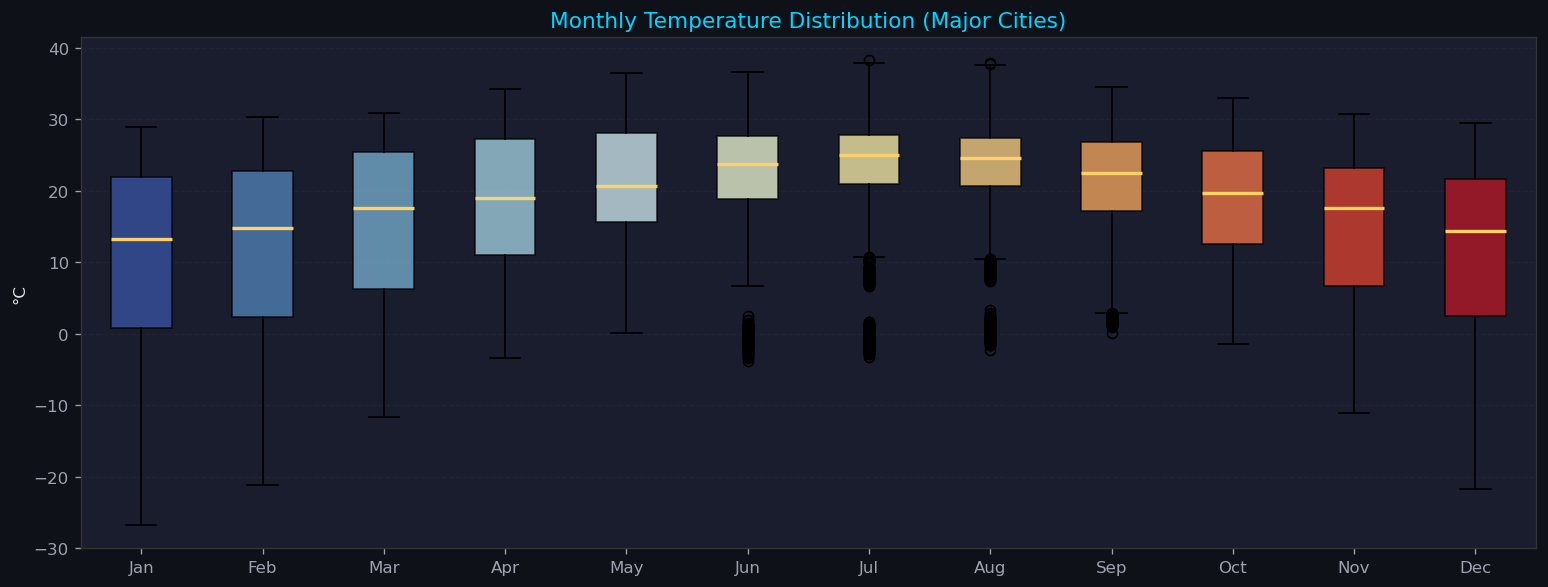

In [59]:
# Monthly box-plot
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
mb_data = monthly_boxplot_data(mc_df)

fig, ax = plt.subplots(figsize=(13, 5))
month_groups = [mb_data[mb_data['month'] == m]['AverageTemperature'].dropna() for m in range(1,13)]
bp = ax.boxplot(month_groups, patch_artist=True, labels=MONTHS,
                medianprops=dict(color=AMBER, linewidth=2))
for patch, color in zip(bp['boxes'],
                         plt.cm.RdYlBu_r(np.linspace(0.05, 0.95, 12))):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_title('Monthly Temperature Distribution (Major Cities)', fontsize=13, color=CYAN)
ax.set_ylabel('°C'); ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()


## 11. Warming Analysis — Pre vs Post 1950

In [60]:
# Split era: pre vs post-1950
pre  = c_df[c_df['year'] < 1950]
post = c_df[c_df['year'] >= 1950]

pre_mean  = pre.groupby('Country')['AverageTemperature'].mean().rename('Pre_1950')
post_mean = post.groupby('Country')['AverageTemperature'].mean().rename('Post_1950')

era_df = pd.concat([pre_mean, post_mean], axis=1).dropna()
era_df['Warming'] = era_df['Post_1950'] - era_df['Pre_1950']
era_df = era_df.sort_values('Warming', ascending=False)

print('Countries that warmed the most (Pre vs Post 1950):')
display(era_df.head(15))


Countries that warmed the most (Pre vs Post 1950):


,Pre_1950,Post_1950,Warming
Country,,,
French Southern And Antarctic Lands,3.545150,5.020803,1.475653
Heard Island And Mcdonald Islands,1.170050,2.598604,1.428554
Kazakhstan,4.854718,5.947931,1.093213
Canada,-5.546814,-4.466149,1.080665
Mongolia,-1.165459,-0.120264,1.045194
Uzbekistan,11.916696,12.955255,1.038560
Turkmenistan,14.427069,15.449116,1.022048
Saint Pierre And Miquelon,3.973377,4.991366,1.017989
Azerbaijan,10.861621,11.872038,1.010417


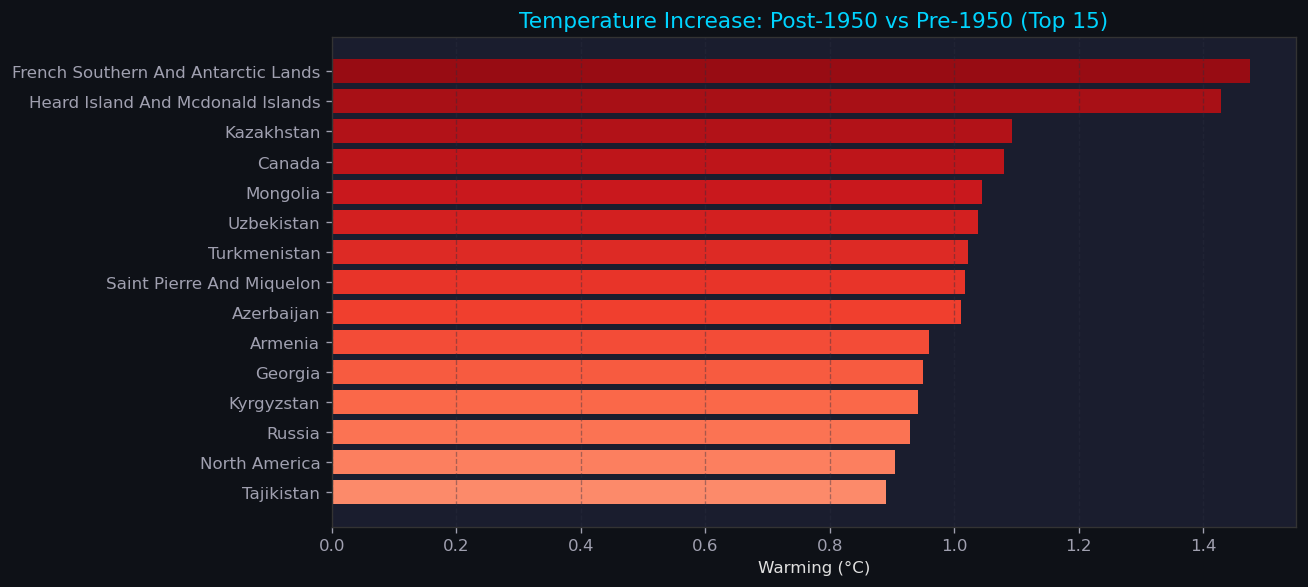

In [61]:
fig, ax = plt.subplots(figsize=(11, 5))
top15 = era_df.head(15)
colors = plt.cm.Reds(np.linspace(0.4, 0.9, 15))
ax.barh(top15.index, top15['Warming'], color=colors[::-1])
ax.set_title('Temperature Increase: Post-1950 vs Pre-1950 (Top 15)', fontsize=13, color=CYAN)
ax.set_xlabel('Warming (°C)')
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.4)
plt.tight_layout(); plt.show()


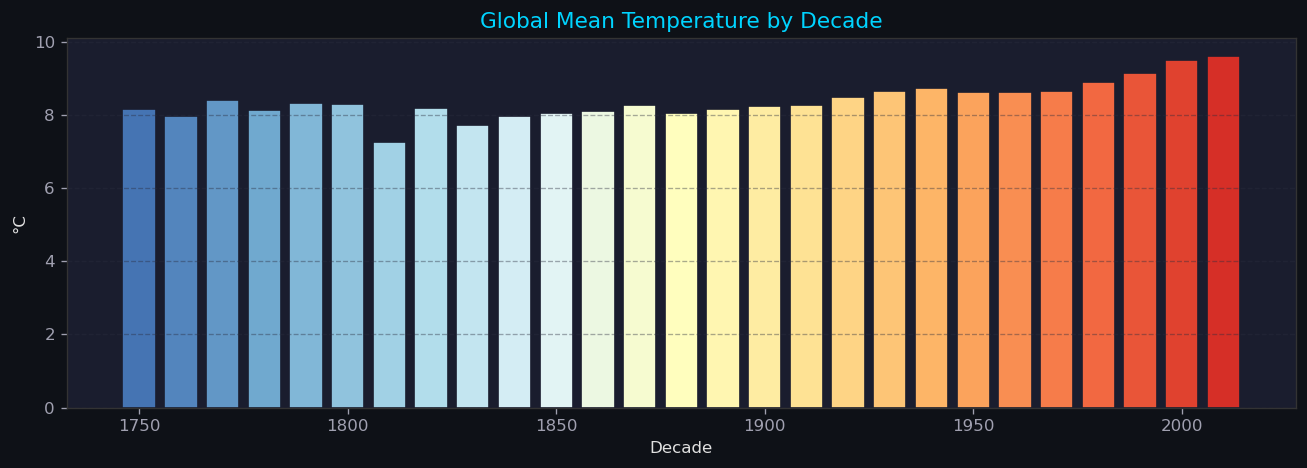

In [62]:
# Global annual mean — decade-level trend
decade_avg = g_df.groupby('decade')['AverageTemperature'].mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(decade_avg.index, decade_avg.values, width=8,
       color=plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(decade_avg))),
       edgecolor='#1A1D2E')
ax.set_title('Global Mean Temperature by Decade', fontsize=13, color=CYAN)
ax.set_xlabel('Decade'); ax.set_ylabel('°C')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()


## 12. US State-Level Patterns

In [63]:
us_states = s_df[s_df['Country'] == 'United States']
if not us_states.empty:
    state_avg = us_states.groupby('State')['AverageTemperature'].mean().dropna().sort_values(ascending=False)
    print(f'{len(state_avg)} US states found')
    display(state_avg.head(10))


51 US states found


State
Hawaii             22.439283
Florida            21.501562
Louisiana          19.128862
Texas              18.107234
Mississippi        17.537407
Georgia (State)    17.527082
Alabama            17.066138
South Carolina     17.034757
Arkansas           15.573963
Oklahoma           15.381547
Name: AverageTemperature, dtype: float64

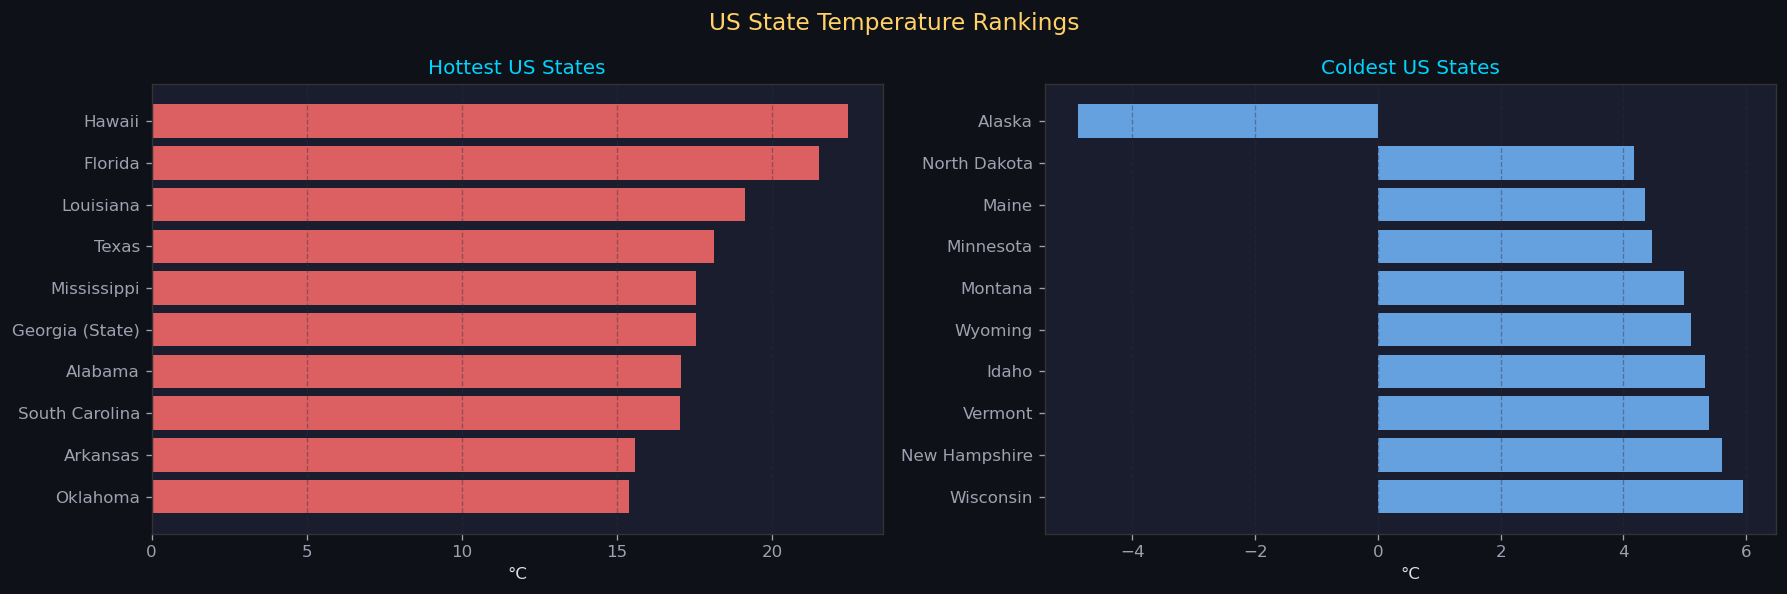

In [64]:
if not us_states.empty:
    top_n  = state_avg.head(10)
    bot_n  = state_avg.tail(10)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].barh(top_n.index, top_n.values, color=RED, alpha=0.85)
    axes[0].invert_yaxis()
    axes[0].set_title('Hottest US States', color=CYAN); axes[0].set_xlabel('°C')
    axes[0].grid(axis='x', alpha=0.4)

    axes[1].barh(bot_n.index, bot_n.values, color='#74B9FF', alpha=0.85)
    axes[1].set_title('Coldest US States', color=CYAN); axes[1].set_xlabel('°C')
    axes[1].grid(axis='x', alpha=0.4)

    plt.suptitle('US State Temperature Rankings', color=AMBER, fontsize=14)
    plt.tight_layout(); plt.show()


## 13. 📝 Key Takeaways

| Finding | Detail |
|---------|--------|
| **Global warming trend** | Clear upward trend from ~1850, accelerating post-1950 |
| **Hottest decade** | 2000s consistently the warmest on record |
| **Seasonal spread** | Summer–Winter gap has narrowed slightly in many regions |
| **Most-warming countries** | Arctic/sub-arctic nations show greatest rise (Russia, Canada, etc.) |
| **Hottest cities** | Equatorial/desert cities (Djibouti, Niamey, etc.) |
| **Coldest cities** | High-latitude Siberian & Canadian cities |
| **Data coverage** | Pre-1850 records are sparse; uncertainty is higher |
| **Missing data** | Temperature uncertainty columns have the most gaps |
